# Part VI — Iterative Methods

## Trefethen & Bau, *Numerical Linear Algebra* (1997) — Lecture 32–40

这是《Numerical Linear Algebra》读书笔记的第 6 册。目标不是摘要原书，而是把每一讲整理成一份**可以独立读懂的数值线性代数讲义**，再把它映射到现代 ML systems。

每一讲尽量保持同一结构：数学对象 → 关键公式 → 几何/算法解释 → numerical stability → ML systems mapping → Python experiment。

本册自洽：下面的 setup cell 提供全部依赖，按顺序 run all 即可。

原书 PDF：https://www.stat.uchicago.edu/~lekheng/courses/309/books/Trefethen-Bau.pdf

---

**本系列共 6 册**（Trefethen & Bau, *Numerical Linear Algebra*, 40 Lectures）

| | |
|---|---|
| Part I | [Fundamentals](01_fundamentals.ipynb) |
| Part II | [QR Factorization and Least Squares](02_qr_least_squares.ipynb) |
| Part III | [Conditioning and Stability](03_conditioning_stability.ipynb) |
| Part IV | [Systems of Equations](04_systems_of_equations.ipynb) |
| Part V | [Eigenvalues](05_eigenvalues.ipynb) |
| Part VI | [Iterative Methods](06_iterative_methods.ipynb) |

索引与阅读顺序见 [00_index.ipynb](00_index.ipynb)。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    import scipy.linalg as sla
    import scipy.sparse.linalg as spla
    SCIPY=True
except Exception:
    SCIPY=False
rng=np.random.default_rng(7)
np.set_printoptions(precision=5,suppress=True)

def relerr(a,b):
    return np.linalg.norm(a-b)/max(np.linalg.norm(b),1e-30)

def stable_rank(A):
    s=np.linalg.svd(A,compute_uv=False)
    return np.sum(s*s)/(s[0]*s[0])

def spectral_norm_power(A,steps=30,seed=0):
    r=np.random.default_rng(seed)
    v=r.normal(size=A.shape[1])
    v/=np.linalg.norm(v)
    for _ in range(steps):
        v=A.T@(A@v)
        v/=np.linalg.norm(v)
    return np.linalg.norm(A@v)

def make_cond(n,kappa,seed=0):
    r=np.random.default_rng(seed)
    Q1,_=np.linalg.qr(r.normal(size=(n,n)))
    Q2,_=np.linalg.qr(r.normal(size=(n,n)))
    s=np.geomspace(1,1/kappa,n)
    return Q1@np.diag(s)@Q2.T

print(f'NumPy {np.__version__} | SciPy {SCIPY}')

NumPy 2.4.2 | SciPy True


## Notation / 贯穿全书的符号

我们主要讨论实矩阵；复数情形把转置 $A^T$ 换成共轭转置 $A^*$。

- $A\in\mathbb{R}^{m\times n}$
- 向量 2-norm：

$$
\Vert x\Vert_2=\sqrt{x^Tx}
$$

- induced matrix 2-norm：

$$
\Vert A\Vert_2=\max_{x\neq0}\frac{\Vert Ax\Vert_2}{\Vert x\Vert_2}=\sigma_{\max}(A)
$$

- Frobenius norm：

$$
\Vert A\Vert_F^2=\sum_{ij}a_{ij}^2=\sum_i\sigma_i^2
$$

- condition number：

$$
\kappa_2(A)=\Vert A\Vert_2\Vert A^{-1}\Vert_2
=\frac{\sigma_{\max}}{\sigma_{\min}}
$$

- unit roundoff：记为 $u$。典型 floating-point model：

$$
\mathrm{fl}(a\circ b)=(a\circ b)(1+\delta),\qquad |\delta|\lesssim u.
$$

计算机算一次加减乘除，不会得到精确的 $a\circ b$，而是得到一个带相对误差的结果。逐项：

- $\mathrm{fl}(\cdot)$：floating-point，机器实际算出来的数；
- $a\circ b$：一次精确运算（$\circ$ 是 $+,-,\times,/$）；
- $\delta$：这次运算引入的相对误差；
- $u$：unit roundoff，这种格式「一次正确舍入」的相对误差上限。

左边是机器结果，右边是「真值再乘 $1+\delta$」。约束的是**相对误差**，不是绝对误差：真值若是 $1.0$，FP32 下次运算大约落在 $1\pm 6\times 10^{-8}$，不会无缘无故错到 $1.01$。

常见 $u$：

- FP32：$u\approx 2^{-24}\approx 6\times 10^{-8}$
- FP16：$u\approx 2^{-11}\approx 5\times 10^{-4}$
- BF16：$u\approx 2^{-8}\approx 4\times 10^{-3}$

一次运算只错 $u$。病态问题可能把这个 $u$ 放大成 $\kappa u$ 量级的解误差。所以不要把「格式很粗」「矩阵很病态」「算法多放大了 rounding」三件事混成一句“数值不稳”。

### 区分

不要把下面三个问题混在一起：

1. **operator amplification**：$\Vert A\Vert$ 大不大？
2. **problem conditioning**：$A^{-1}$ 是否敏感？
3. **algorithm stability**：实现是否额外放大 rounding error？

现代 ML numerics 中，大量争论其实是把这三个层次混在了一起。

# Lecture 32 — Overview of Iterative Methods

### 1. Iterative method 的一般形式

对

$$
Ax=b,
$$

不一定 factorize $A$。可以构造 sequence $x_k\to x_*$。

经典 stationary splitting：

$$
A=M-N.
$$

迭代

$$
Mx_{k+1}=Nx_k+b,
$$

即

$$
x_{k+1}=Gx_k+c,
\qquad G=M^{-1}N.
$$

误差满足

$$
e_{k+1}=Ge_k.
$$

因此收敛需要

$$
\rho(G)<1.
$$

### 2. Krylov philosophy

更现代的方法不固定一个 stationary matrix $G$，而是在

$$
\mathcal K_k(A,r_0)=\mathrm{span}\{r_0,Ar_0,\ldots,A^{k-1}r_0\}
$$

中寻找最优 approximation。

### 3. ML scale

如果参数数目是千万级，显式 Hessian 不可能存。HVP 可以给你 $Hv$，于是 Krylov methods 仍然成立。

**ML numerics 自测**

**Q1.** stationary iteration 何时收敛？

**A.** $A=M-N$，$x_{k+1}=Gx_k+c$，$G=M^{-1}N$。误差 $e_{k+1}=Ge_k$，需要 $\rho(G)<1$。

**Q2.** Krylov 方法和固定 $G$ 的差别是什么？

**A.** 不固定一个 stationary $G$，而在 $\mathcal{K}_k(A,r_0)=\mathrm{span}\{r_0,Ar_0,\ldots,A^{k-1}r_0\}$ 里找逐步更优的近似。

**Q3.** 千万参数时 Hessian 怎么还能用这些方法？

**A.** 不存显式 $H$。HVP 给你 $Hv$，Krylov 仍然成立。

**Q4.** 该先问“能不能分解 $A$”，还是“能不能做 matvec”？

**A.** 大规模先问 matvec / HVP 是否便宜。能做 $Av$ 就可以迭代；分解往往根本存不下。


# Lecture 33 — The Arnoldi Iteration

### 1. Arnoldi 构造 Krylov orthonormal basis

从 $q_1=b/\Vert b\Vert$ 开始。第 $k$ 步计算

$$
v=Aq_k,
$$

然后把已有 basis components 去掉：

$$
h_{jk}=q_j^Tv,
\qquad
v\leftarrow v-h_{jk}q_j,
\quad j=1,\ldots,k.
$$

最后

$$
h_{k+1,k}=\Vert v\Vert,
\qquad
q_{k+1}=v/h_{k+1,k}.
$$

### 2. Arnoldi relation

把前 $k$ 个 basis 合成 $Q_k$：

$$
AQ_k=Q_{k+1}\bar H_k,
$$

其中 $\bar H_k$ 是 $(k+1)\times k$ upper Hessenberg。

等价地，

$$
Q_k^TAQ_k=H_k.
$$

所以巨大 operator 被压缩为小 Hessenberg projected operator。

### 3. Numerical problem

理论上 $Q_k^TQ_k=I$。floating point 下，如果新 vector 接近旧 Krylov span，Gram–Schmidt cancellation 会让 orthogonality 丢失。实际高质量 Arnoldi 往往需要 reorthogonalization。

In [25]:
def arnoldi(A,q,k):
    q=q/np.linalg.norm(q)
    n=len(q)
    Q=np.zeros((n,k+1))
    H=np.zeros((k+1,k))
    Q[:,0]=q
    for j in range(k):
        v=A@Q[:,j]
        for i in range(j+1):
            H[i,j]=Q[:,i]@v
            v-=H[i,j]*Q[:,i]
        H[j+1,j]=np.linalg.norm(v)
        if H[j+1,j]<1e-14: return Q[:,:j+1],H[:j+1,:j]
        Q[:,j+1]=v/H[j+1,j]
    return Q,H
A=rng.normal(size=(120,120))
Q,H=arnoldi(A,rng.normal(size=120),20)
print(f'Q shape {Q.shape} orthogonality {np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]))}')

Q shape (120, 21) orthogonality 1.4265591201166386e-15


**ML numerics 自测**

**Q1.** Arnoldi 在构造什么？

**A.** Krylov 空间的标准正交基底。$AQ_k=Q_{k+1}\bar H_k$，或 $Q_k^TAQ_k=H_k$：大算子被压成小 Hessenberg。

**Q2.** 最危险的数值步骤是哪一步？

**A.** 从 $Aq_k$ 里减掉旧 basis。新向量接近旧 Krylov span 时，Gram–Schmidt cancellation 让 $\Vert Q^TQ-I\Vert$ 炸掉。

**Q3.** 高质量实现通常还要多做什么？

**A.** reorthogonalization。理论 $Q_k^TQ_k=I$ 在浮点下不会自己保住。

**Q4.** ML 里 Arnoldi 的产出是完整 $Q$，还是小 $H_k$？

**A.** 通常要的是小 projected operator $H_k$（再拿 Ritz）。完整 $Q$ 只在需要 Ritz 向量时才留。


# Lecture 34 — How Arnoldi Locates Eigenvalues

### 1. Ritz pair

对 projected matrix

$$
H_k=Q_k^TAQ_k,
$$

求

$$
H_ky=\theta y.
$$

定义 Ritz vector

$$
u=Q_ky.
$$

则 $(\theta,u)$ 近似 $A$ 的 eigenpair。

### 2. Residual 有漂亮的公式

Arnoldi relation：

$$
AQ_k=Q_kH_k+h_{k+1,k}q_{k+1}e_k^T.
$$

于是

$$
Au-\theta u
=h_{k+1,k}q_{k+1}e_k^Ty.
$$

因此

$$
\Vert Au-\theta u\Vert_2
=|h_{k+1,k}|\,|e_k^Ty|.
$$

不需要回到 full matrix 做 expensive residual，就可以判断 Ritz pair 是否 converged。

### 3. ML mapping

Hessian Lanczos/Arnoldi diagnostics 中，Ritz residual 比“跑固定 20 steps 就认为 eigenvalue 准了”更 principled。

In [26]:
n=100
Q0,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.linspace(-5,20,n)
A=Q0@np.diag(ev)@Q0.T
q=rng.normal(size=n)
for k in [4,8,16,30]:
    Q,Hb=arnoldi(A,q,k)
    H=Hb[:k,:k]
    ritz=np.linalg.eigvalsh((H+H.T)/2)
    print(f'k {k} Ritz min/max {ritz[0]} {ritz[-1]}')
print(f'true min/max {ev[0]} {ev[-1]}')

k 4 Ritz min/max -3.674517751862945 18.114504831981566
k 8 Ritz min/max -4.33651197916984 19.828609393886495
k 16 Ritz min/max -4.898339977998647 19.99457037919067
k 30 Ritz min/max -4.999846274386212 19.999995560173325
true min/max -5.0 20.0


**ML numerics 自测**

**Q1.** Ritz pair $(\theta,u)$ 是怎么来的？

**A.** 对 $H_k=Q_k^TAQ_k$ 求 $H_ky=\theta y$，再 $u=Q_ky$。这是 $A$ 的近似特征对。

**Q2.** 为什么不必回到大矩阵就能判断收敛？

**A.** $Au-\theta u=h_{k+1,k}q_{k+1}e_k^Ty$，故 $\Vert Au-\theta u\Vert_2=|h_{k+1,k}|\,|e_k^Ty|$。

**Q3.** “跑固定 20 步就算 eigenvalue 准了”有什么问题？

**A.** 没有 residual 判据。Hessian Lanczos/Arnoldi 诊断应当看 Ritz residual，而不是步数迷信。

**Q4.** 该报 $\theta$ 还是该报 Ritz residual？

**A.** 两个都报。没有 residual 的 $\theta$ 不能当已经收敛的特征值用。


# Lecture 35 — GMRES

### 1. GMRES 的 optimization problem

要解 nonsymmetric

$$
Ax=b.
$$

初值 $x_0$，residual

$$
r_0=b-Ax_0,
\qquad \beta=\Vert r_0\Vert.
$$

GMRES 在 affine Krylov space

$$
x_k\in x_0+\mathcal K_k(A,r_0)
$$

中最小化 residual：

$$
x_k=\arg\min_{x\in x_0+\mathcal K_k}\Vert b-Ax\Vert_2.
$$

### 2. Arnoldi 把大问题变成小 least squares

写

$$
x_k=x_0+Q_ky.
$$

利用

$$
AQ_k=Q_{k+1}\bar H_k,
\qquad
r_0=\beta q_1=Q_{k+1}\beta e_1,
$$

得到

$$
r_k=Q_{k+1}(\beta e_1-\bar H_ky).
$$

因为 $Q_{k+1}$ orthonormal，

$$
\Vert r_k\Vert_2
=\Vert \beta e_1-\bar H_ky\Vert_2.
$$

所以每一步只需要解一个小 least-squares problem。

### 3. Polynomial view

GMRES residual 可写成

$$
r_k=p_k(A)r_0,
\qquad p_k(0)=1.
$$

于是 convergence 取决于能否找到在 $A$ spectrum/pseudospectrum 上很小的 polynomial。

### 4. 系统 tradeoff

GMRES residual norm 单调不增，但要保存整个 Arnoldi basis，memory 随 $k$ 增长。restart 降低 memory，却可能把有价值的 Krylov information 丢掉。

In [27]:
if SCIPY:
    n=120
    A=rng.normal(size=(n,n))/np.sqrt(n)+3*np.eye(n)
    xt=rng.normal(size=n)
    b=A@xt
    hist=[]
    x,info=spla.gmres(A,b,rtol=1e-10,atol=0,restart=40,callback=lambda r:hist.append(float(r)),callback_type='pr_norm')
    print(f'info {info} solution error {relerr(x, xt)} iterations {len(hist)}')
else: print(f'SciPy unavailable')

info 0 solution error 6.95596483447139e-11 iterations 20


**ML numerics 自测**

**Q1.** GMRES 每步在优化什么？

**A.** 在 $x_0+\mathcal{K}_k(A,r_0)$ 里最小化 $\Vert b-Ax\Vert_2$。residual 单调不增。

**Q2.** Arnoldi 怎样把大问题变成小 least squares？

**A.** $x_k=x_0+Q_ky$，$r_k=Q_{k+1}(\beta e_1-\bar H_ky)$。$Q$ 正交，故 $\Vert r_k\Vert_2=\Vert\beta e_1-\bar H_ky\Vert_2$。

**Q3.** 收敛由什么多项式决定？

**A.** $r_k=p_k(A)r_0$、$p_k(0)=1$。能否在 $A$ 的 spectrum / pseudospectrum 上把 $p_k$ 压小。

**Q4.** restart 的 tradeoff 是什么？

**A.** 不 restart 要存整个 Arnoldi basis，memory 随 $k$ 涨。restart 省内存，但丢掉已有 Krylov 信息，可能停滞。


# Lecture 36 — The Lanczos Iteration

### 1. Symmetry 把 Arnoldi 简化成 Lanczos

若 $A=A^T$，Arnoldi projected matrix

$$
H_k=Q_k^TAQ_k
$$

也 symmetric。但它同时是 upper Hessenberg，所以只能是 tridiagonal：

$$
T_k=
\begin{bmatrix}
\alpha_1&\beta_1\\
\beta_1&\alpha_2&\beta_2\\
&\ddots&\ddots&\ddots\\
&&\beta_{k-1}&\alpha_k
\end{bmatrix}.
$$

### 2. 三项 recurrence

$$
Aq_k=\beta_{k-1}q_{k-1}+\alpha_kq_k+\beta_kq_{k+1}.
$$

因此 ideal exact arithmetic 下无需对所有旧 basis 做 full orthogonalization。

### 3. 为什么 Hessian 特别适合 Lanczos

Hessian 是 symmetric operator。只要有 HVP $v\mapsto Hv$，就可以构造小 $T_k$，其 eigenvalues (Ritz values) 近似 Hessian spectrum extremes。

### 4. Finite precision catch

三项 recurrence 的 exact orthogonality 在 floating point 会慢慢丢失，已收敛的 Ritz direction 可能“重新出现”，产生 ghost eigenvalues。必要时要 selective/full reorthogonalization。

In [28]:
def lanczos(A,q,k):
    n=len(q)
    q=q/np.linalg.norm(q)
    Q=np.zeros((n,k))
    alpha=np.zeros(k)
    beta=np.zeros(k-1)
    qprev=np.zeros(n)
    b=0.
    for j in range(k):
        Q[:,j]=q
        z=A@q
        if j>0: z-=b*qprev
        a=q@z
        z-=a*q
        z-=Q[:,:j+1]@(Q[:,:j+1].T@z)
        alpha[j]=a
        if j<k-1:
            b=np.linalg.norm(z)
            beta[j]=b
            if b<1e-14: break
            qprev=q
            q=z/b
    T=np.diag(alpha)+np.diag(beta,1)+np.diag(beta,-1)
    return Q,T
n=180
Q0,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.geomspace(.01,100,n)
A=Q0@np.diag(ev)@Q0.T
Qk,T=lanczos(A,rng.normal(size=n),30)
r=np.linalg.eigvalsh(T)
print(f'Ritz min/max {r[0]} {r[-1]} true {ev[0]} {ev[-1]}')

Ritz min/max 0.038988058445983055 100.0 true 0.01 100.0


**ML numerics 自测**

**Q1.** 为什么对称时 Arnoldi 变成 Lanczos？

**A.** $A=A^T$ 则 $H_k=Q_k^TAQ_k$ 又对称又 Hessenberg，只能是三对角 $T_k$。于是有三项递推 $Aq_k=\beta_{k-1}q_{k-1}+\alpha_k q_k+\beta_k q_{k+1}$。

**Q2.** exact arithmetic 下为什么不必对全部旧 basis 正交化？

**A.** 三项递推已经隐含与更早向量正交。这是对称带来的结构，不是实现偷懒。

**Q3.** 浮点下会出现什么假象？

**A.** orthogonality 慢慢丢，已收敛的 Ritz 方向会“回来”，产生 ghost eigenvalues。需要 selective/full reorthogonalization。

**Q4.** 为何 Hessian 特别适合 Lanczos？

**A.** Hessian 对称，又有 HVP。小 $T_k$ 的特征值就能近似谱的两端。


# Lecture 37 — From Lanczos to Gauss Quadrature

### 1. 从 matrix function 到 spectral measure

若 $A=A^T=Q\Lambda Q^T$，则

$$
v^Tf(A)v
=\sum_i (q_i^Tv)^2 f(\lambda_i).
$$

这可以看成关于 eigenvalue spectral measure 的积分：

$$
v^Tf(A)v=\int f(\lambda)\,d\mu_v(\lambda).
$$

### 2. Lanczos quadrature

运行 $k$ 步 Lanczos 得到 $T_k$。一个关键近似是

$$
v^Tf(A)v
\approx
\Vert v\Vert^2 e_1^Tf(T_k)e_1.
$$

如果

$$
T_k=S\Theta S^T,
$$

则

$$
e_1^Tf(T_k)e_1
=\sum_j S_{1j}^2 f(\theta_j),
$$

正是一个 Gauss quadrature rule。

### 3. ML applications

- $f(\lambda)=\lambda$：trace/curvature moments；
- $f(\lambda)=1/\lambda$：inverse curvature quadratic forms；
- $f(\lambda)=\log\lambda$：logdet-like quantities；
- kernelized $f$：spectral density。

结合 random probe $v$ 就得到 stochastic Lanczos quadrature (SLQ) 的基础。

In [29]:
n=140
Q0,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.geomspace(.2,30,n)
A=Q0@np.diag(ev)@Q0.T
v=rng.normal(size=n)
nv=np.linalg.norm(v)
Qk,T=lanczos(A,v/nv,30)
th,S=np.linalg.eigh(T)
approx=nv**2*np.sum((S[0,:]**2)/th)
exact=v@np.linalg.solve(A,v)
print(f'exact {exact} Lanczos quadrature {approx} relative error {abs(approx - exact) / abs(exact)}')

exact 103.53147604786616 Lanczos quadrature 103.52635405646723 relative error 4.947279411498997e-05


**ML numerics 自测**

**Q1.** $v^Tf(A)v$ 为什么是谱上的积分？

**A.** $A=Q\Lambda Q^T$ 时 $v^Tf(A)v=\sum_i(q_i^Tv)^2 f(\lambda_i)=\int f(\lambda)\,d\mu_v(\lambda)$。

**Q2.** Lanczos quadrature 的公式是什么？

**A.** $v^Tf(A)v\approx\Vert v\Vert^2 e_1^T f(T_k)e_1$。$T_k=S\Theta S^T$ 后就是权 $S_{1j}^2$、节点 $\theta_j$ 的 Gauss 求积。

**Q3.** ML 里 $f(\lambda)$ 常见取什么？

**A.** $\lambda$：trace/曲率矩；$1/\lambda$：inverse curvature；$\\log\lambda$：logdet-like；再加随机 $v$ 就是 SLQ。

**Q4.** 这还需要每个特征值都算准吗？

**A.** 不需要。要的是对某个 $f$ 的谱积分，不是完整 eigendecomposition。


# Lecture 38 — Conjugate Gradients

### 1. CG 是 quadratic optimization

对 SPD $A$，定义

$$
\phi(x)=\frac12x^TAx-b^Tx.
$$

梯度

$$
\nabla\phi(x)=Ax-b=-r.
$$

stationary point 就是

$$
Ax=b.
$$

### 2. A-conjugate directions

CG 构造搜索方向 $p_i$，满足

$$
p_i^TAp_j=0\quad(i\neq j).
$$

这比 Euclidean orthogonality 更匹配 quadratic geometry。

### 3. Krylov optimality

第 $k$ 步解满足

$$
x_k\in x_0+\mathcal K_k(A,r_0)
$$

并最小化 A-norm error：

$$
\Vert x_*-x_k\Vert_A
=\min_{x\in x_0+\mathcal K_k}\Vert x_*-x\Vert_A,
$$

其中

$$
\Vert e\Vert_A=\sqrt{e^TAe}.
$$

### 4. Condition-number convergence bound

经典 bound：

$$
\frac{\Vert e_k\Vert_A}{\Vert e_0\Vert_A}
\le
2\left(
\frac{\sqrt\kappa-1}{\sqrt\kappa+1}
\right)^k.
$$

这个 bound 解释为什么 $\kappa$ 大时 CG 慢，但实际 convergence 还受 eigenvalue clustering 影响，往往比 worst-case bound 更好。

### 5. Optimization mapping

damped Newton/Gauss–Newton：

$$
(H+\lambda I)p=-g
$$

如果可用 HVP，就可以 CG matrix-free solve。

iterations 180 solution error 0.09533671182751831


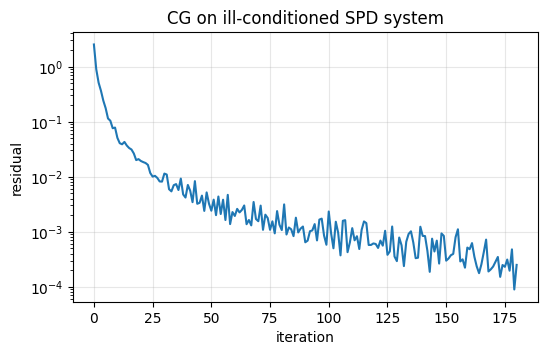

In [30]:
def cg(A,b,maxiter=250,tol=1e-10):
    x=np.zeros_like(b)
    r=b-A@x
    p=r.copy()
    rr=r@r
    h=[np.sqrt(rr)]
    for _ in range(maxiter):
        Ap=A@p
        a=rr/(p@Ap)
        x+=a*p
        r-=a*Ap
        rrn=r@r
        h.append(np.sqrt(rrn))
        if np.sqrt(rrn)<tol: break
        p=r+(rrn/rr)*p
        rr=rrn
    return x,np.array(h)
n=140
Q0,_=np.linalg.qr(rng.normal(size=(n,n)))
ev=np.geomspace(1,1e-5,n)
A=Q0@np.diag(ev)@Q0.T
xt=rng.normal(size=n)
b=A@xt
x,h=cg(A,b,180)
print(f'iterations {len(h) - 1} solution error {relerr(x, xt)}')
plt.figure(figsize=(6,3.5))
plt.semilogy(h)
plt.xlabel('iteration')
plt.ylabel('residual')
plt.title('CG on ill-conditioned SPD system')
plt.grid(True,alpha=.3)
plt.show()

**ML numerics 自测**

**Q1.** CG 对应的优化问题是什么？

**A.** SPD 上 $\phi(x)=\frac12 x^TAx-b^Tx$。$\nabla\phi=Ax-b$，驻点就是 $Ax=b$。

**Q2.** 它在哪个范数下最优？

**A.** 第 $k$ 步在 $x_0+\mathcal{K}_k$ 里最小化 $\Vert x_*-x\Vert_A$，$\Vert e\Vert_A=\sqrt{e^TAe}$。方向满足 $p_i^TAp_j=0$。

**Q3.** 经典 bound 和 $\kappa$ 的关系？

**A.** $\Vert e_k\Vert_A/\Vert e_0\Vert_A\le 2((\sqrt{\kappa}-1)/(\sqrt{\kappa}+1))^k$。$\kappa$ 大则慢；实际还受 eigenvalue clustering 影响，常好于 worst-case。

**Q4.** damped Newton 怎么接上 CG？

**A.** $(H+\lambda I)p=-g$。有 HVP 就可以 matrix-free CG，不必存 $H$。


# Lecture 39 — Biorthogonalization Methods

### 1. 为什么 nonsymmetric matrix 没有 Lanczos 的简单正交结构

对 general $A$，右 Krylov space 用 $A$，左 Krylov space 用 $A^T$：

$$
\mathcal K_k(A,v_1),
\qquad
\mathcal K_k(A^T,w_1).
$$

构造两组 basis $V_k,W_k$，满足 biorthogonality：

$$
W_k^TV_k=I.
$$

### 2. 两侧 projection

可以得到类似

$$
AV_k=V_kT_k+\cdots,
\qquad
A^TW_k=W_kT_k^T+\cdots
$$

的短 recurrence。

### 3. Benefit / cost

优点：不像 GMRES 那样必须保存 growing orthonormal basis，memory 低。

代价：

- 不再最小化 2-norm residual；
- denominator 可能接近 0，引发 breakdown；
- residual 常常 nonmonotone。

BiCGSTAB 是把 BiCG residual 行为“平滑化”的实用变体之一。

In [31]:
if SCIPY:
    n=150
    A=rng.normal(size=(n,n))/np.sqrt(n)+2.5*np.eye(n)
    xt=rng.normal(size=n)
    b=A@xt
    hist=[]
    x,info=spla.bicgstab(A,b,rtol=1e-10,atol=0,maxiter=500,callback=lambda xk:hist.append(np.linalg.norm(b-A@xk)))
    print(f'info {info} solution error {relerr(x, xt)} iterations {len(hist)}')
else: print(f'SciPy unavailable')

info 0 solution error 3.862140021869542e-11 iterations 13


**ML numerics 自测**

**Q1.** nonsymmetric 时为什么要两套 Krylov？

**A.** 右空间用 $A$，左空间用 $A^T$。构造 $V_k,W_k$ 使 $W_k^TV_k=I$（biorthogonality），才能维持短递推。

**Q2.** 相对 GMRES 的收益和代价是什么？

**A.** 收益：不必存增长的正交基底，memory 低。代价：不再最小化 2-norm residual；分母可接近 0 而 breakdown；residual 常非单调。

**Q3.** BiCGSTAB 在修什么？

**A.** 把 BiCG 那种抖的 residual 行为平滑化，是更常用的实用变体。

**Q4.** 什么时候不该用这类方法？

**A.** 你需要单调、可解释的 $\Vert r\Vert_2$ 下降，或 breakdown 不可接受时，应回到 GMRES（或加更好的 preconditioner）。


# Lecture 40 — Preconditioning

### 1. Preconditioning 的目标

原问题

$$
Ax=b.
$$

找一个容易 invert 的 $M\approx A$。

**Left preconditioning**：

$$
M^{-1}Ax=M^{-1}b.
$$

**Right preconditioning**：

$$
AM^{-1}y=b,
\qquad x=M^{-1}y.
$$

### 2. 为什么会加速

对 SPD/CG，理想上希望

$$
\kappa(M^{-1}A)\ll\kappa(A),
$$

更进一步，希望 eigenvalues clustered around 1。

如果

$$
M=A,
$$

当然一步解决，但 preconditioner 本身就和原问题一样贵。实际是在“每步成本”和“iteration reduction”之间 trade off。

### 3. Jacobi example

$$
M=\operatorname{diag}(A).
$$

它只做 coordinate-wise scaling，廉价但只能修复一部分 anisotropy。

### 4. Optimization mapping

一个 badly scaled quadratic：

$$
\frac12x^THx
$$

在 Euclidean coordinates 中是窄长 valley。preconditioning 相当于换坐标，把 valley 尽量变圆。

这和 Adam 类 adaptive scaling 有概念联系，但不能简单把 Adam 等同于 classical preconditioned CG。

CG iters 250 PCG iters 188


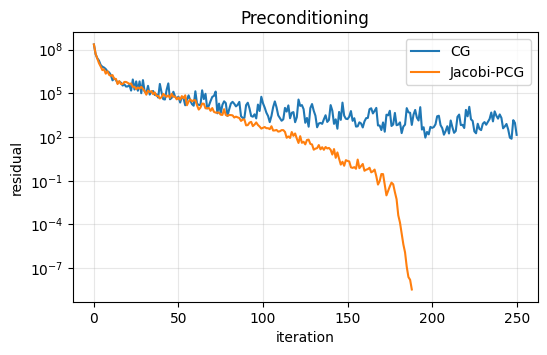

In [32]:
def pcg_diag(A,b,maxiter=250,tol=1e-8):
    Mi=1/np.diag(A)
    x=np.zeros_like(b)
    r=b-A@x
    z=Mi*r
    p=z.copy()
    rz=r@z
    h=[np.linalg.norm(r)]
    for _ in range(maxiter):
        Ap=A@p
        a=rz/(p@Ap)
        x+=a*p
        r-=a*Ap
        h.append(np.linalg.norm(r))
        if h[-1]<tol: break
        z=Mi*r
        rzn=r@z
        p=z+(rzn/rz)*p
        rz=rzn
    return x,np.array(h)
n=120
R=rng.normal(size=(n,n))
B=R.T@R+.5*np.eye(n)
s=np.geomspace(1e-3,1e3,n)
D=np.diag(s)
A=D@B@D
xt=rng.normal(size=n)
b=A@xt
_,h1=cg(A,b,250,1e-8)
_,h2=pcg_diag(A,b,250,1e-8)
print(f'CG iters {len(h1) - 1} PCG iters {len(h2) - 1}')
plt.figure(figsize=(6,3.5))
plt.semilogy(h1,label='CG')
plt.semilogy(h2,label='Jacobi-PCG')
plt.legend()
plt.xlabel('iteration')
plt.ylabel('residual')
plt.title('Preconditioning')
plt.grid(True,alpha=.3)
plt.show()

In [33]:
def qint8(x,axis=None):
    if axis is None:
        a=np.max(np.abs(x))
        s=a/127 if a>0 else 1.
    else:
        a=np.max(np.abs(x),axis=axis,keepdims=True)
        s=np.where(a>0,a/127,1.)
    return np.clip(np.round(x/s),-127,127)*s
X=rng.normal(size=(4096,64))
X[:,7]*=35
Xt=qint8(X)
Xc=qint8(X,0)
print(f'per-tensor error {relerr(Xt, X)}')
print(f'per-channel error {relerr(Xc, X)}')

per-tensor error 0.061033007086233215
per-channel error 0.007904102358807293


In [34]:
dims=[64,64,64,64,32]
Ws=[rng.normal(scale=.08,size=(dims[i+1],dims[i])) for i in range(len(dims)-1)]
u=rng.normal(size=64)
u/=np.linalg.norm(u)
v=rng.normal(size=64)
v/=np.linalg.norm(v)
Ws[2]+=8*np.outer(u,v)
def fwd(Ws,x):
    for W in Ws: x=W@x
    return x
x=rng.normal(size=64)
y=fwd(Ws,x)
print(f'layer  local_weight_error  final_output_error')
for i in range(len(Ws)):
    Wq=[w.copy() for w in Ws]
    Wq[i]=Wq[i].astype(np.float16).astype(float)
    yq=fwd(Wq,x)
    print(f'{i} {relerr(Wq[i], Ws[i])} {relerr(yq, y)}')

layer  local_weight_error  final_output_error
0 0.00020199560567719108 9.128981963807791e-05
1 0.00020828373065435275 0.00013344761242405797
2 0.00020861254641664975 0.0001224397069047388
3 0.0002092168252893803 0.00019933537150459188


**ML numerics 自测**

**Q1.** preconditioning 在改哪个问题？

**A.** 找便宜的 $M\approx A$。左：$M^{-1}Ax=M^{-1}b$；右：$AM^{-1}y=b$、$x=M^{-1}y$。目标是 $\kappa(M^{-1}A)\ll\kappa(A)$，最好特征值聚在 1 附近。

**Q2.** 为什么 $M=A$ 不是合法答案？

**A.** 一步就解完，但 preconditioner 和原问题一样贵。实际是在每步成本和迭代次数之间折中。

**Q3.** Jacobi $M=\mathrm{diag}(A)$ 能修什么、不能修什么？

**A.** 只做坐标缩放，廉价，只能修一部分 anisotropy，不能修掉真正的病态耦合。

**Q4.** 和 Adam 能画等号吗？

**A.** 概念上都在改坐标、把窄长 valley 变圆一些。但不能把 Adam 等同于 classical preconditioned CG。


# Synthesis A — Training Numerics: 从 layer spectrum 到 checkpoint sensitivity

对深度网络局部线性化：

$$
\delta h_{\ell+1}=J_\ell\delta h_\ell+\epsilon_\ell,
$$

其中 $\epsilon_\ell$ 可以代表 rounding、quantization、optimizer-induced perturbation 或 upstream representation drift。

展开到输出：

$$
\delta h_L
\approx
\sum_{\ell=0}^{L-1}
J_{L-1}J_{L-2}\cdots J_{\ell+1}\epsilon_\ell.
$$

因此某层是否“load bearing”取决于两件事：

1. 它产生多大的 local perturbation；
2. 该 perturbation 之后会经过多大的 downstream gain。

这解释了为什么：

- 最大 weight diff 的 layer 不一定造成最大 behavior diff；
- local FP16 error 很小的 layer 也可能是 precision-sensitive layer；
- 高 $\sigma_{\max}$ / low stable-rank direction 可能成为 variance carrier。

一个 principled profiler 应同时记录：

$$
\sigma_{\max}(W),\quad
\Vert W\Vert_F,\quad
r_{stable},\quad
\Vert \nabla W\Vert,\quad
\Vert \Delta W\Vert/\Vert W\Vert,
$$

以及 downstream task perturbation。

# Synthesis B — Optimization Numerics: curvature, damping, CG, preconditioning

局部二次模型：

$$
L(\theta+p)
\approx
L(\theta)+g^Tp+\frac12p^THp.
$$

Newton step：

$$
Hp=-g.
$$

如果 $H$ 有极小 positive eigenvalues，step 沿这些方向非常大：

$$
p_i=-\frac{g_i}{\lambda_i}.
$$

这既是 optimization sensitivity，也是 numerical sensitivity。

Damping：

$$
(H+\lambda I)p=-g
$$

把

$$
\frac1{\lambda_i}
\quad\to\quad
\frac1{\lambda_i+\lambda}.
$$

它不是“为了让 Cholesky 不报错而打补丁”，而是在明确限制 weak-curvature directions 的 inverse gain。

如果 $H$ 太大无法 factorize：

- HVP + Lanczos：看 spectrum；
- HVP + CG：solve；
- preconditioner：改善 geometry。

这三者是同一套 Krylov / spectral framework 的不同用途。

# Synthesis C — Deployment Numerics: precision allocation 应该怎样 principled

设 reference operator $f$ 在某一局部输入 $x$ 附近：

$$
f(x+\delta x)\approx f(x)+J\delta x.
$$

低精度 kernel 产生 local error $\epsilon$，则 downstream error 近似

$$
\delta y\approx J\epsilon.
$$

因此 precision decision 不能只按 operator name：

> `softmax always FP32`, `matmul always BF16`

这些只能作为经验起点。真正的 decision variable 应该是

$$
\underbrace{\Vert \epsilon\Vert}_{\text{local numeric error}}
\times
\underbrace{\Vert J\Vert}_{\text{downstream sensitivity}}
$$

以及 task-level error budget。

特别高风险的结构：

### Gram / normal-equation construction

$$
G=A^TA
$$

不仅可能 overflow/accumulate error，还会把 conditioning 平方。

### Cholesky
small pivot 对 low precision 极敏感。

### Quantization outliers
per-tensor scale 被一个 channel 控制时，其余 directions resolution 下降。

### Non-normal high-gain layer
即使 eigenvalues 看起来稳定，$\sigma_{\max}$ 仍可能非常大。

这也是为什么 deployment parity 最终是 numerical linear algebra 问题，而不只是“比较两个输出 tensor”。

# Suggested Projects / 真正把这本书变成 ML numerics 工具

## Project 1 — Spectral training monitor
每 N steps 对关键 layer 做 power iteration：

$$
\sigma_{\max}(W_\ell).
$$

同时记录 stable rank、WUR、gradient norm，观察在 divergence/checkpoint variance 前后谁先变化。

## Project 2 — Representation subspace stability
对 activation matrix $X$ 做 QR/SVD，比较 checkpoint 的 projector：

$$
P=QQ^T.
$$

避免把 arbitrary basis rotation 误判成 representation drift。

## Project 3 — Hessian matrix-free diagnostics
用 HVP 实现：

1. power iteration；
2. Lanczos Ritz spectrum；
3. CG solve $(H+\lambda I)p=-g$；
4. sweep $\lambda$ 看 convergence 与 step norm。

## Project 4 — Precision sensitivity harness
逐层注入 BF16/FP16/INT8 perturbation：

$$
\epsilon_\ell=\hat h_\ell-h_\ell.
$$

同时比较 local error 与 final task error，建立 mixed-precision allocation。

## Project 5 — Solver torture test
构造控制以下变量的 matrix family：

- $\kappa$；
- $\lambda_{min}$；
- non-normality；
- scaling range；
- pivot growth；
- rank deficiency。

验证 custom/compiled solver 的 residual、forward error、backward error，而不是只做 random smoke test。